Датасет был найден на платформе Kaggle при целенаправленном поиске задач с денежным (monetary) таргетом и без пометки “Getting Started”. Были перебраны несколько вариантов и окончательный выбор пал на Global Black Money Transactions Dataset, который описывает 10 000 финансовых транзакций с полем Amount (USD) в качестве основной суммы операции.

Выбор именно этого набора данных обусловлен несколькими причинами:

Monetary-таргет. Каждая строка содержит сумму транзакции Amount (USD), что позволяет сформулировать чистую задачу регрессии по денежной величине, как требовалось по условиям проекта.

Богатый набор признаков. Помимо суммы, датасет включает страну отправителя и получателя, тип транзакции, индустрию, источник денег, участие офшоров, количество компаний-прокладок и оценку риска отмывания денег (Money Laundering Risk Score). Это даёт простор для feature engineering и анализа зависимостей.

Нешаблонная тематика. Тематика борьбы с отмыванием денег (AML) встречается реже классических датасетов вроде Titanic или доменных цен, поэтому проект выглядит менее тривиально и лучше демонстрирует умение работать с нестандартными бизнес-кейсами.

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/black_money_transactions.csv")
df.head()

,Transaction ID,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
0,TX0000000001,Brazil,3.267530e+06,Offshore Transfer,2013-01-01 00:00:00,Person_1101,Construction,USA,True,Illegal,6,1,Bank_40,Singapore
1,TX0000000002,China,4.965767e+06,Stocks Transfer,2013-01-01 01:00:00,Person_7484,Luxury Goods,South Africa,False,Illegal,9,0,Bank_461,Bahamas
2,TX0000000003,UK,9.416750e+04,Stocks Transfer,2013-01-01 02:00:00,Person_3655,Construction,Switzerland,True,Illegal,1,3,Bank_387,Switzerland
3,TX0000000004,UAE,3.864201e+05,Cash Withdrawal,2013-01-01 03:00:00,Person_3226,Oil & Gas,Russia,False,Illegal,7,2,Bank_353,Panama
4,TX0000000005,South Africa,6.433784e+05,Cryptocurrency,2013-01-01 04:00:00,Person_7975,Real Estate,USA,True,Illegal,1,9,Bank_57,Luxembourg


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction ID               10000 non-null  str    
 1   Country                      10000 non-null  str    
 2   Amount (USD)                 10000 non-null  float64
 3   Transaction Type             10000 non-null  str    
 4   Date of Transaction          10000 non-null  str    
 5   Person Involved              10000 non-null  str    
 6   Industry                     10000 non-null  str    
 7   Destination Country          10000 non-null  str    
 8   Reported by Authority        10000 non-null  bool   
 9   Source of Money              10000 non-null  str    
 10  Money Laundering Risk Score  10000 non-null  int64  
 11  Shell Companies Involved     10000 non-null  int64  
 12  Financial Institution        10000 non-null  str    
 13  Tax Haven Country           

In [4]:
df.describe()

,Amount (USD),Money Laundering Risk Score,Shell Companies Involved
count,1.000000e+04,10000.000000,10000.000000
mean,2.501818e+06,5.526400,4.469400
std,1.424364e+06,2.893603,2.879773
min,1.003180e+04,1.000000,0.000000
25%,1.279005e+06,3.000000,2.000000
50%,2.501310e+06,6.000000,4.000000
75%,3.722416e+06,8.000000,7.000000
max,4.999812e+06,10.000000,9.000000


Совершили небольшую предобработку:  
Amount (USD):
среднее ≈ 2.5 млн, минимум ≈ 10k, максимум ≈ 5 млн — распределение широкое, явно есть смысл сделать лог-таргет и в дальнейшем экспериментировать.   
закодировали бинарные категориальные признаки в числовые

In [8]:
import pandas as pd

train = pd.read_csv("../data/processed/train.csv")
valid = pd.read_csv("../data/processed/valid.csv")
test  = pd.read_csv("../data/processed/test.csv")

df = pd.concat([train, valid, test], axis=0, ignore_index=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      10000 non-null  str    
 1   Transaction Type             10000 non-null  str    
 2   Industry                     10000 non-null  str    
 3   Destination Country          10000 non-null  str    
 4   Reported by Authority        10000 non-null  bool   
 5   Source of Money              10000 non-null  str    
 6   Money Laundering Risk Score  10000 non-null  int64  
 7   Shell Companies Involved     10000 non-null  int64  
 8   Financial Institution        10000 non-null  str    
 9   Tax Haven Country            10000 non-null  str    
 10  transaction_year             10000 non-null  int64  
 11  transaction_month            10000 non-null  int64  
 12  transaction_dayofweek        10000 non-null  int64  
 13  transaction_hour            

In [9]:
df.head()

,Country,Transaction Type,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Amount (USD)
0,Switzerland,Cryptocurrency,Luxury Goods,South Africa,True,Illegal,10,3,Bank_202,Panama,2013,7,5,2,1,1,1,13.623577,8.253611e+05
1,India,Offshore Transfer,Oil & Gas,Russia,False,Illegal,10,9,Bank_12,Singapore,2013,9,3,16,1,0,1,13.222104,5.524413e+05
2,USA,Property Purchase,Luxury Goods,Russia,True,Legal,5,1,Bank_352,Cayman Islands,2013,9,2,10,0,1,1,14.945248,3.094842e+06
3,Switzerland,Stocks Transfer,Real Estate,Russia,False,Illegal,3,0,Bank_469,Luxembourg,2014,1,6,3,1,0,1,14.746832,2.537859e+06
4,China,Cash Withdrawal,Construction,South Africa,False,Illegal,1,3,Bank_140,Singapore,2013,6,2,23,1,0,1,14.920456,3.019059e+06


In [11]:
cat_cols = [
    "Country",
    "Transaction Type",
    "Industry",
    "Destination Country",
    "Source of Money",
    "Financial Institution",
    "Tax Haven Country",
]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print("nunique:", df[col].nunique())
    print(df[col].value_counts().head(15))


=== Country ===
nunique: 10
Country
China           1038
South Africa    1026
UK              1014
Brazil          1006
Russia           997
Singapore        995
India            990
Switzerland      985
UAE              976
USA              973
Name: count, dtype: int64

=== Transaction Type ===
nunique: 5
Transaction Type
Property Purchase    2086
Stocks Transfer      1983
Offshore Transfer    1980
Cash Withdrawal      1978
Cryptocurrency       1973
Name: count, dtype: int64

=== Industry ===
nunique: 7
Industry
Finance         1475
Construction    1460
Luxury Goods    1459
Real Estate     1443
Arms Trade      1414
Casinos         1377
Oil & Gas       1372
Name: count, dtype: int64

=== Destination Country ===
nunique: 10
Destination Country
USA             1061
Russia          1035
India           1032
Singapore        999
South Africa     989
Switzerland      987
China            986
UK               981
UAE              970
Brazil           960
Name: count, dtype: int64

=== Sour

Видим: все категориальные признаки, кроме Financial Institution, содержат не более 10-и категорий, one-hot кодирование будет хорошо применимо. Так как у фичи Financial Institution 499 уникальных значений, с отсутвием 15-20 лидеров по количеству объектов, избавимся от этой фичи.

В исходном датасете было 14 колонок. В качестве таргета выбрана Amount (USD), а чисто идентификаторные поля (Transaction ID, Person Involved) были исключены. Дата транзакции Date of Transaction преобразована в формат datetime, из неё выделены числовые признаки transaction_year, transaction_month, transaction_dayofweek и transaction_hour. На основе категориальных признаков построены бинарные индикаторы: is_illegal (незаконный источник средств), is_reported (сообщена ли транзакция регулятору). Для таргета дополнительно рассчитан логарифм log_amount = log1p(Amount (USD))

In [12]:
train = pd.read_csv("../data/processed/train.csv")
valid = pd.read_csv("../data/processed/valid.csv")
test  = pd.read_csv("../data/processed/test.csv")

df = pd.concat([train, valid, test], ignore_index=True)

In [29]:
df.head()

,Country,Transaction Type,Industry,Destination Country,Money Laundering Risk Score,Shell Companies Involved,Tax Haven Country,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Financial Institution_grouped,Amount (USD)
0,Switzerland,Cryptocurrency,Luxury Goods,South Africa,10,3,Panama,2013,7,5,2,1,1,1,13.623577,OTHER,8.253611e+05
1,India,Offshore Transfer,Oil & Gas,Russia,10,9,Singapore,2013,9,3,16,1,0,1,13.222104,OTHER,5.524413e+05
2,USA,Property Purchase,Luxury Goods,Russia,5,1,Cayman Islands,2013,9,2,10,0,1,1,14.945248,OTHER,3.094842e+06
3,Switzerland,Stocks Transfer,Real Estate,Russia,3,0,Luxembourg,2014,1,6,3,1,0,1,14.746832,OTHER,2.537859e+06
4,China,Cash Withdrawal,Construction,South Africa,1,3,Singapore,2013,6,2,23,1,0,1,14.920456,OTHER,3.019059e+06


In [28]:
df.describe()

,Money Laundering Risk Score,Shell Companies Involved,transaction_year,transaction_month,transaction_dayofweek,transaction_hour,is_illegal,is_reported,has_tax_haven,log_amount,Amount (USD)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,1.000000e+04
mean,5.526400,4.469400,2013.124000,5.890400,2.994400,11.493600,0.701700,0.200500,1.0,14.446425,2.501818e+06
std,2.893603,2.879773,0.329598,3.646768,1.994685,6.921297,0.457535,0.400395,0.0,0.939696,1.424364e+06
min,1.000000,0.000000,2013.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,9.213615,1.003180e+04
25%,3.000000,2.000000,2013.000000,2.000000,1.000000,5.000000,0.000000,0.000000,1.0,14.061594,1.279005e+06
50%,6.000000,4.000000,2013.000000,6.000000,3.000000,11.000000,1.000000,0.000000,1.0,14.732326,2.501310e+06
75%,8.000000,7.000000,2013.000000,9.000000,5.000000,17.000000,1.000000,0.000000,1.0,15.129884,3.722416e+06
max,10.000000,9.000000,2014.000000,12.000000,6.000000,23.000000,1.000000,1.000000,1.0,15.424911,4.999812e+06


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

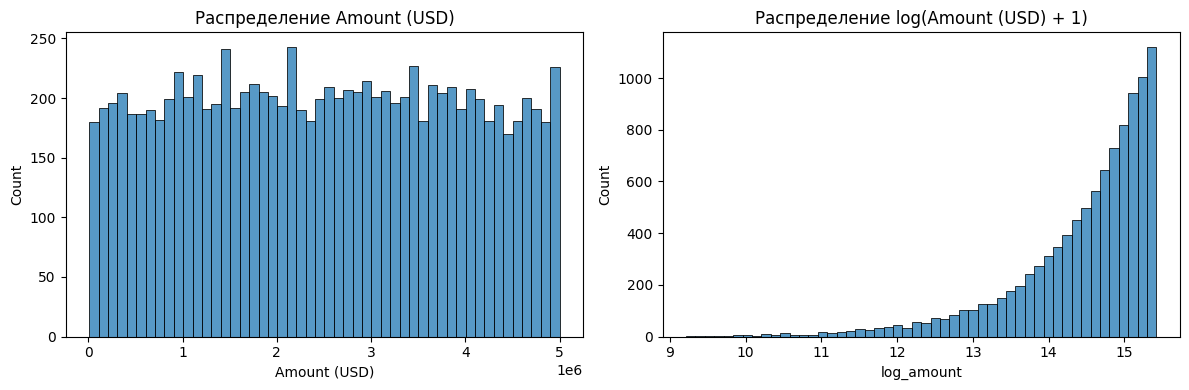

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Amount (USD)"], bins=50, ax=axes[0])
axes[0].set_title("Распределение Amount (USD)")
axes[0].set_xlabel("Amount (USD)")

sns.histplot(np.log1p(df["Amount (USD)"]), bins=50, ax=axes[1])
axes[1].set_title("Распределение log(Amount (USD) + 1)")
axes[1].set_xlabel("log_amount")

plt.tight_layout()
plt.show()

В отличие от многих реальных финансовых наборов данных, распределение Amount (USD) в данном датасете оказывается близким к равномерному по диапазону [10k; 5M], что видно по почти одинаковой высоте столбиков гистограммы. Логарифмирование таргета в этом случае не приводит к более симметричному распределению; наоборот, распределение log_amount становится более скошенным.

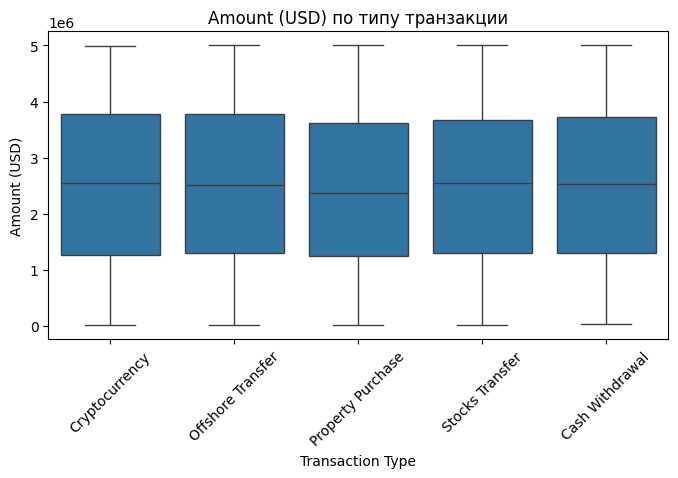

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Transaction Type", y="Amount (USD)")
plt.xticks(rotation=45)
plt.title("Amount (USD) по типу транзакции")
plt.show()

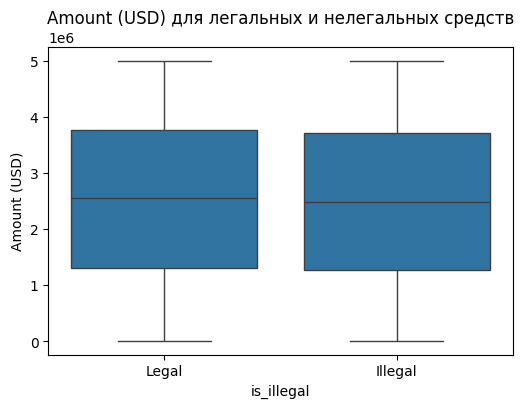

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="is_illegal", y="Amount (USD)")
plt.xticks([0, 1], ["Legal", "Illegal"])
plt.title("Amount (USD) для легальных и нелегальных средств")
plt.show()

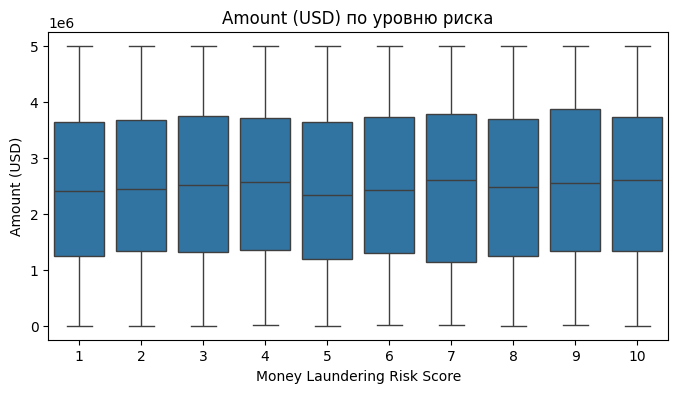

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Money Laundering Risk Score", y="Amount (USD)")
plt.title("Amount (USD) по уровню риска")
plt.show()

Видим максимальную медиану на уровне риска "Выше среднего" - ожидаемо.

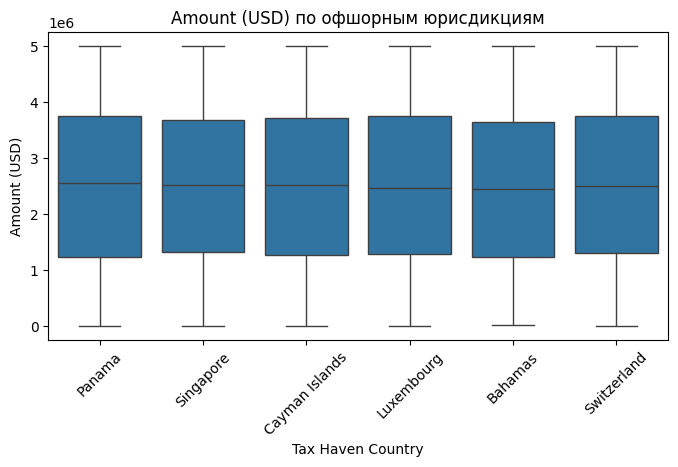

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Tax Haven Country", y="Amount (USD)")
plt.xticks(rotation=45)
plt.title("Amount (USD) по офшорным юрисдикциям")
plt.show()

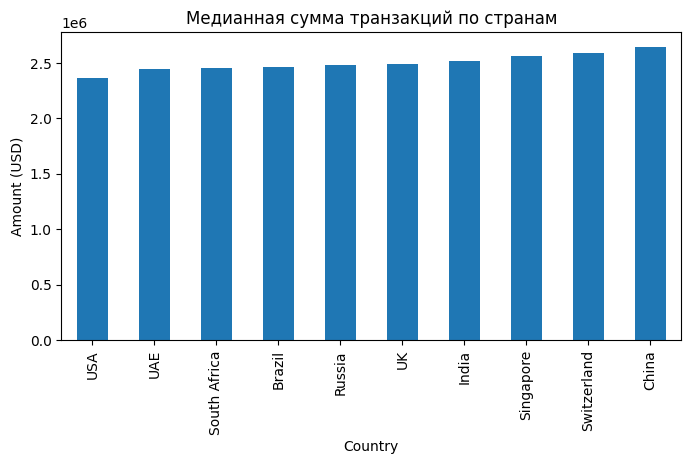

In [26]:
plt.figure(figsize=(8, 4))
df.groupby("Country")["Amount (USD)"].median().sort_values().plot(kind="bar")
plt.title("Медианная сумма транзакций по странам")
plt.ylabel("Amount (USD)")
plt.show()

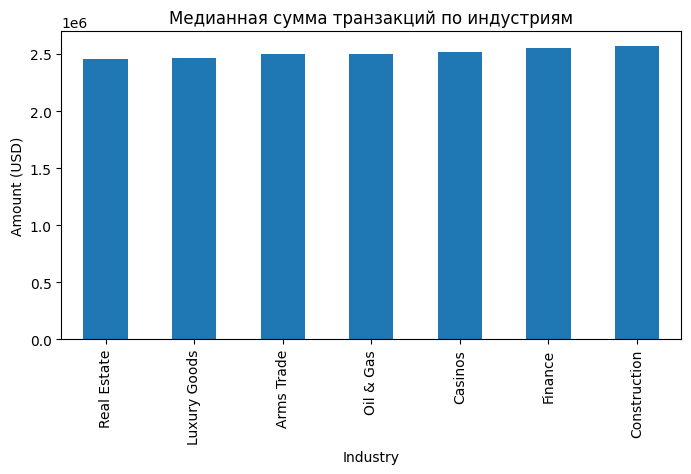

In [27]:
plt.figure(figsize=(8, 4))
df.groupby("Industry")["Amount (USD)"].median().sort_values().plot(kind="bar")
plt.title("Медианная сумма транзакций по индустриям")
plt.ylabel("Amount (USD)")
plt.show()

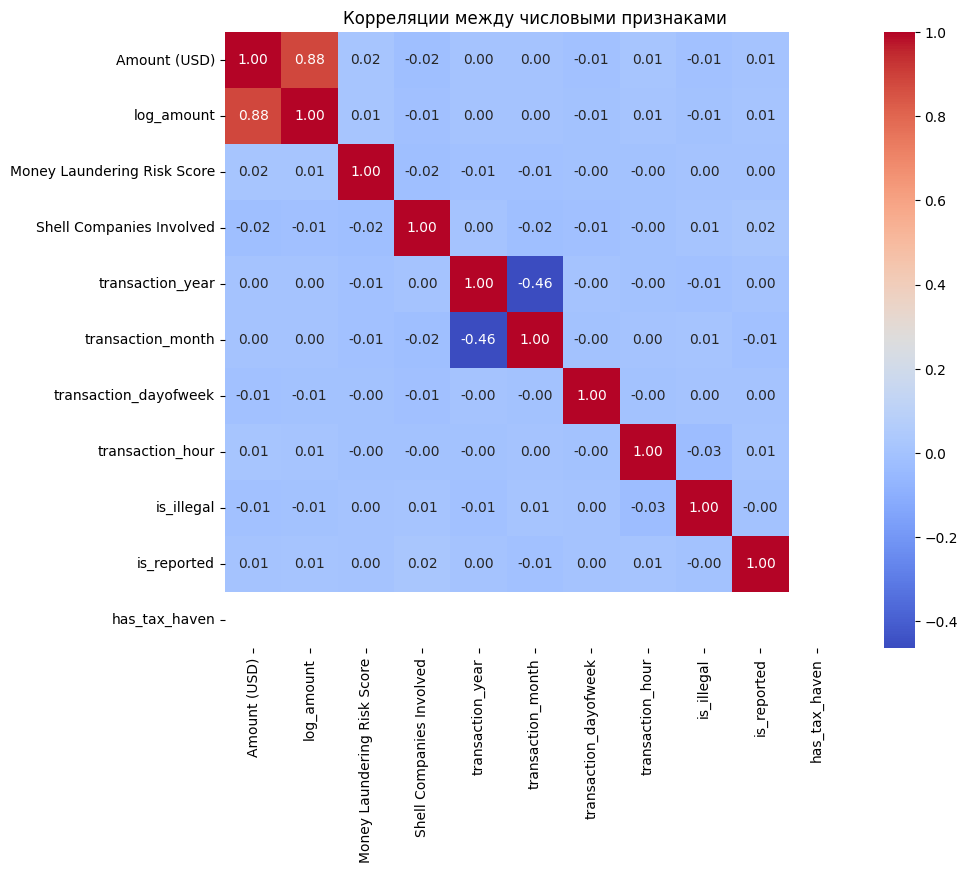

In [25]:
numeric_cols = [
    "Amount (USD)",
    "log_amount",
    "Money Laundering Risk Score",
    "Shell Companies Involved",
    "transaction_year",
    "transaction_month",
    "transaction_dayofweek",
    "transaction_hour",
    "is_illegal",
    "is_reported",
    "has_tax_haven",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляции между числовыми признаками")
plt.show()

На корреляционной матрице видно, что таргет Amount (USD) ожидаемо сильно коррелирует со своей логарифмической версией log_amount (коэффициент ≈ 0.88), что подтверждает корректность вычисления лог-таргета. При этом ни одна из остальных числовых фич (оценка риска отмывания Money Laundering Risk Score, количество компаний-прокладок Shell Companies Involved, временные признаки и бинарные индикаторы is_illegal, is_reported) не демонстрирует существенной линейной связи с суммой транзакции: абсолютные значения коэффициентов корреляции с Amount (USD) находятся в диапазоне около 0.00–0.02.

Единственное заметное соотношение — отрицательная корреляция между transaction_year и transaction_month (≈ −0.46), которая, скорее всего, объясняется синтетическим характером дат, но это не влияет на таргет. В целом матрица показывает, что линейных зависимостей между признаками и Amount (USD) почти нет, и модель должна опираться на более сложные (нелинейные) комбинации признаков; это дополнительно мотивирует использование бустинговых/деревянных моделей, а не только линейной регрессии.

Поскольку задача представляет собой регрессию с денежным таргетом Amount (USD), в качестве основной метрики качества была выбрана RMSE (Root Mean Squared Error). Эта метрика измеряется в тех же единицах, что и таргет, но при этом квадратично штрафует большие ошибки, что важно в финансовом контексте: большие промахи по крупным транзакциям должны влиять на итоговую оценку сильнее, чем небольшие ошибки на маленьких суммах.

В качестве дополнительной метрики использована MAE (Mean Absolute Error), которая также измеряется в долларах и показывает типичную величину ошибки модели. MAE менее чувствительна к выбросам и удобна для интерпретации (“в среднем модель ошибается на X долларов”), однако при сравнении моделей приоритет отдаётся RMSE как более строгой метрике.
